<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Learning%20and%20Optimization/Batch_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from collections import OrderedDict

In [ ]:
class BatchNormalization:
  def __init__(self,gamma,beta,eps=1e-6,momentum=0.9):
    self.x=None
    self.gamma=gamma
    self.beta=beta
    self.mu=None
    self.var=None
    self.eps=eps
    self.x_hat=None
    self.running_mean = None
    self.running_var = None
    self.momentum = momentum
    self.dgamma=None
    self.dbeta=None


  def forward(self,x,train=True):
    gamma=self.gamma
    beta=self.beta
    eps=self.eps
    if self.running_mean is None:
      self.running_mean = np.zeros_like(gamma)
      self.running_var = np.zeros_like(gamma)

    m=x.shape[0]

    if train:
      self.x=x
      mu=np.sum(x,axis=0)/m
      self.mu=mu
      var=np.sum((x-mu)**2,axis=0)/m
      self.var=var
      x_hat=(x-mu)/np.sqrt(var+eps)
      self.x_hat=x_hat

      self.running_mean=self.momentum*self.running_mean+(1-self.momentum)*mu
      self.running_var=self.momentum*self.running_var+(1-self.momentum)*var
    else:
      x_hat=(x-self.running_mean)/np.sqrt(self.running_var+eps)
    return gamma*x_hat+beta

  def backward(self,dout):
    m=dout.shape[0]
    dx_hat=dout*self.gamma
    dvar=-np.sum(dx_hat*(self.x-self.mu)*(self.var+self.eps)**(-3/2),axis=0)/2
    dmu=-np.sum(dx_hat*(self.var+self.eps)**(-1/2),axis=0)
    dx=dx_hat*(self.var+self.eps)**(-1/2)+dvar*2*(self.x-self.mu)/m+dmu/m
    self.dgamma=np.sum(dout*self.x_hat,axis=0)
    self.dbeta=np.sum(dout,axis=0)
    return dx


In [ ]:
class Sigmoid:
  def __init__(self):
    self.out=None

  def forward(self,x):
    out=1/(1+np.exp(-x))
    self.out=out
    return out

  def backward(self,dout):
    dx=dout*self.out*(1-self.out)
    return dx

In [ ]:
class ReLU:
  def __init__(self):
    self.mask=None

  def forward(self,x):
    self.mask=(x<=0)
    out=x.copy()
    out[self.mask]=0
    return out

  def backward(self,dout):
    dout[self.mask]=0
    dx=dout
    return dx

In [ ]:
class Affine:
  def __init__(self,W,b):
    self.W=W
    self.b=b
    self.x=None
    self.dW=None
    self.db=None

  def forward(self,x):
    self.x=x
    out=x@self.W+self.b
    return out

  def backward(self,dout):
    dx=dout@self.W.T
    self.dW=self.x.T@dout
    self.db=np.sum(dout,axis=0)
    return dx

In [ ]:
class Adam:
  def __init__(self,lr=0.001,beta1=0.9,beta2=0.999):
    self.lr=lr
    self.beta1=beta1
    self.beta2=beta2
    self.t=0
    self.m=None
    self.v=None

  def update(self,params,grads):
    if self.m is None:
      self.m={}
      self.v={}
      for key,val in params.items():
        self.m[key]=np.zeros_like(val)
        self.v[key]=np.zeros_like(val)

    self.t+=1
    for key in params.keys():
      #print(key)
      grad=grads[key]
      self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*grad
      self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*grad**2
      m_hat=self.m[key]/(1-self.beta1**self.t)
      v_hat=self.v[key]/(1-self.beta2**self.t)
      params[key]-=self.lr*m_hat/(np.sqrt(v_hat)+1e-8)

In [ ]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))


In [ ]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size


In [ ]:
class SoftmaxWithLoss:
  def __init__(self):
    self.loss=None
    self.y=None
    self.t=None

  def forward(self,x,t):
    self.t=t
    self.y=softmax(x)
    self.loss=cross_entropy_error(self.y,self.t)
    return self.loss

  def backward(self,dout=1):
    batch_size=self.t.shape[0]
    dx=(self.y-self.t)/batch_size
    return dx


In [ ]:
class SimpleNet:
  def __init__(self,input_size,hidden_size,output_size,use_bn=True,weight_init_std=0.1):
    self.params={}
    self.params['W1']=weight_init_std*np.random.randn(input_size,hidden_size)
    self.params['b1']=np.zeros(hidden_size)
    self.use_bn=use_bn
    if use_bn:
      self.params['gamma']=np.ones(hidden_size)
      self.params['beta']=np.zeros(hidden_size)

    self.params['W2']=weight_init_std*np.random.randn(hidden_size,output_size)
    self.params['b2']=np.zeros(output_size)

    self.layers=OrderedDict()
    self.layers['Affine1']=Affine(self.params['W1'],self.params['b1'])

    if use_bn:
      self.layers['Batch']=BatchNormalization(self.params['gamma'],self.params['beta'])

    self.layers['ReLU']=ReLU()
    self.layers['Affine2']=Affine(self.params['W2'],self.params['b2'])

    self.criterion=SoftmaxWithLoss()

  def predict(self,x,train=True):
    for layer in self.layers.values():
      if isinstance(layer,BatchNormalization):
        x=layer.forward(x,train)
      else:
        x=layer.forward(x)

    return x

  def loss(self,x,t):
    y=self.predict(x)
    return self.criterion.forward(y,t)

  def accuracy(self,x,t):
    y=self.predict(x,train=False)
    y=np.argmax(y,axis=1)
    if t.ndim != 1:t=np.argmax(t,axis=1)

    accuracy=np.sum(y==t)/float(x.shape[0])
    return accuracy

  def gradient(self,x,t):
    self.loss(x,t)

    dout=1
    dout=self.criterion.backward(dout)

    layers=list(self.layers.values())
    layers.reverse()
    for layer in layers:
      dout=layer.backward(dout)

    grads={}
    grads['W1']=self.layers['Affine1'].dW
    grads['b1']=self.layers['Affine1'].db
    grads['W2']=self.layers['Affine2'].dW
    grads['b2']=self.layers['Affine2'].db
    if self.use_bn:
      grads['gamma']=self.layers['Batch'].dgamma
      grads['beta']=self.layers['Batch'].dbeta
    return grads

In [ ]:
from tensorflow.keras.datasets import mnist
from tqdm import tqdm

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float32) / 255.0

# 원핫 인코딩
y_train = np.eye(10)[y_train]  # (60000, 10)
y_test  = np.eye(10)[y_test]   # (10000, 10)

In [ ]:
network_w_bn=SimpleNet(784,50,10)
network_wo_bn=SimpleNet(784,50,10,use_bn=False)
optim1=Adam()
optim2=Adam()

In [ ]:
train_size=X_train.shape[0]
batch_size=100
lr=0.01
epochs=5

train_loss_list=[[],[]]
train_acc_list=[[],[]]
test_acc_list=[[],[]]

for epoch in range(epochs):

  indices=np.random.permutation(train_size)
  for i in tqdm(range(0,train_size,batch_size),desc="Batch"):
    batch_indices=indices[i:i+batch_size]
    batch_x=X_train[batch_indices]
    batch_t=y_train[batch_indices]

    grad1=network_w_bn.gradient(batch_x,batch_t)
    grad2=network_wo_bn.gradient(batch_x,batch_t)

    '''
    for key in network_w_bn.params.keys():
      print(key,end=' ')

    print()
    for key in grad1.keys():
      print(key,end=' ')
      '''


    optim1.update(network_w_bn.params,grad1)
    optim2.update(network_wo_bn.params,grad2)

    train_loss_list[0].append(network_w_bn.loss(batch_x,batch_t))
    train_loss_list[1].append(network_wo_bn.loss(batch_x,batch_t))

  train_acc1=network_w_bn.accuracy(X_train,y_train)
  test_acc1=network_w_bn.accuracy(X_test,y_test)
  train_acc_list[0].append(train_acc1)
  test_acc_list[0].append(test_acc1)
  train_acc2=network_wo_bn.accuracy(X_train,y_train)
  test_acc2=network_wo_bn.accuracy(X_test,y_test)
  train_acc_list[1].append(train_acc2)
  test_acc_list[1].append(test_acc2)
  print("with BN : "+str(test_acc1)+", without BN : "+str(test_acc2))

Batch: 100%|██████████| 600/600 [00:07<00:00, 83.77it/s] 


with BN : 0.9308, without BN : 0.9285


Batch: 100%|██████████| 600/600 [00:04<00:00, 135.49it/s]


with BN : 0.9509, without BN : 0.9437


Batch: 100%|██████████| 600/600 [00:07<00:00, 82.95it/s] 


with BN : 0.9591, without BN : 0.9542


Batch: 100%|██████████| 600/600 [00:04<00:00, 134.78it/s]


with BN : 0.9628, without BN : 0.9592


Batch: 100%|██████████| 600/600 [00:07<00:00, 83.71it/s] 


with BN : 0.9649, without BN : 0.9618


In [ ]:
from matplotlib import pyplot as plt

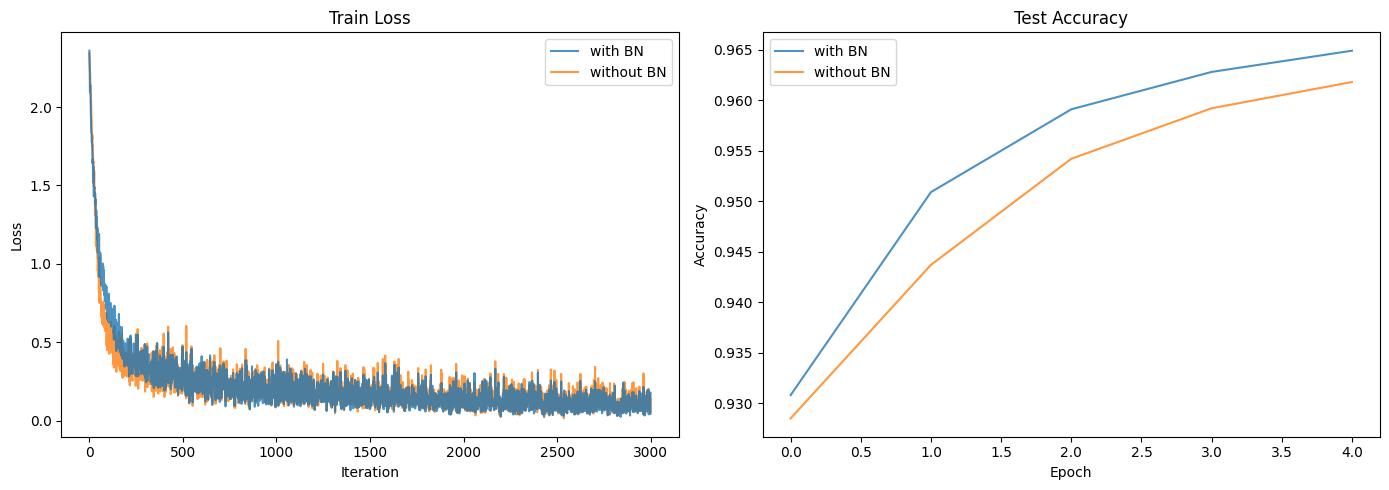

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(train_loss_list[0], label="with BN", alpha=0.8,zorder=2)
axes[0].plot(train_loss_list[1], label="without BN", alpha=0.8,zorder=1)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy 그래프
axes[1].plot(test_acc_list[0], label="with BN", alpha=0.8)
axes[1].plot(test_acc_list[1], label="without BN", alpha=0.8)
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

아래는 ReLU대신 Sigmoid를 썼을때 나온 그래프임.
+ weight_init_std가 0.01이었음

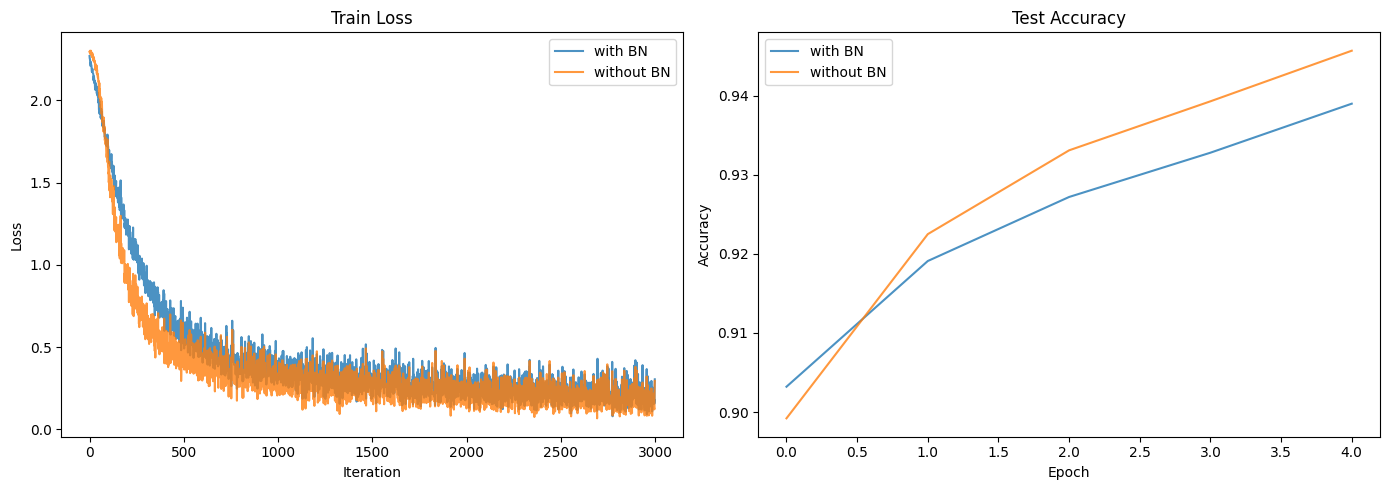